In [1]:
# Instalacion de las librerías: XGBoost, Scikit-learn, Matplotlib/Seaborn y TensorFlow.
!pip install xgboost scikit-learn matplotlib seaborn tensorflow -q

import pandas as pd # Manejo de datos en tablas.

import numpy as np # Operaciones matemáticas y manejo de matrices

import matplotlib.pyplot as plt # Librería para visualizacion

import seaborn as sns # Librería para gráficas

import warnings # Gestion de mensajes de advertencia
warnings.filterwarnings('ignore')

#SCIKIT-LEARN
from sklearn.linear_model import LogisticRegression # Modelo de regresión logística
from sklearn.ensemble import RandomForestClassifier # Modelo múltiples árboles de decisión
from sklearn.preprocessing import StandardScaler # Para estandarizar los datos
# Herramientas para evaluar
from sklearn.metrics import (confusion_matrix, f1_score, accuracy_score,
                             roc_auc_score, roc_curve, classification_report)
from sklearn.impute import SimpleImputer

import xgboost as xgb # Algoritmo de Gradient Boosting

# TENSORFLOW
import tensorflow as tf # Librería principal
from tensorflow.keras.models import Sequential # Clase para crear modelos capa por capa
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau # Funciones para detener el entrenamiento

sns.set_style('whitegrid') # Configura visual de las gráficas

PAL = ['#1565C0','#2E7D32','#E65100','#AD1457'] # Define una paleta de colores

# Imprime un mensaje de las versiones actuales de TF y XGBoost
print(f"✅ Listo | TF {tf.__version__} | XGB {xgb.__version__}")

✅ Listo | TF 2.19.0 | XGB 3.2.0


In [2]:
# Importa la herramienta de google colab
from google.colab import files

uploaded = files.upload() # Abre una interfaz para que selecciones del archivos

# Lee el archivo CSV y lo convierte en un DataFrame de Pandas
# 'parse_dates' convierte la columna FECHA en formato de tiempo real(DD/MM/AAAA)
df = pd.read_csv('dataset_sonora_completo (3).csv', parse_dates=['FECHA'], dayfirst=True)

print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas") # Imprime el tamaño del dataset
print(f"   Período: {df['FECHA'].min().date()} → {df['FECHA'].max().date()}") # Muestra el rango de tiempo que cubren los datos
print(f"   Nulos: {df.isnull().sum().sum()}")

display(df.head(3)) # Muestra una tabla con las primeras 3 filas del dataset.

Saving dataset_sonora_completo (3).csv to dataset_sonora_completo (3) (1).csv
✅ Dataset cargado: 13,645 filas × 17 columnas
   Período: 1931-01-01 → 2025-10-12
   Nulos: 0


,FECHA,PRECIP_mean,PRECIP_max,TMAX_mean,TMIN_mean,EVAP_mean,RH2M,PRECTOTCORR,AOD_55,ALLSKY_SFC_SW_DWN,cont_SO_2,cont_CO,cont_NOx,cont_COV,cont_PM_010,cont_PM_2_5,cont_NH_3
0,1931-01-01,0.0,0.0,13.0,0.0,3.3755,43.47,0.0,0.04,4.2425,20611.021,240997.256,75245.086,138370.855,52329.735,29400.143,28719.614
1,1931-01-02,0.0,0.0,15.0,1.0,3.3755,43.47,0.0,0.04,4.2425,20611.021,240997.256,75245.086,138370.855,52329.735,29400.143,28719.614
2,1931-01-03,0.0,0.0,12.0,1.0,3.3755,43.47,0.0,0.04,4.2425,20611.021,240997.256,75245.086,138370.855,52329.735,29400.143,28719.614


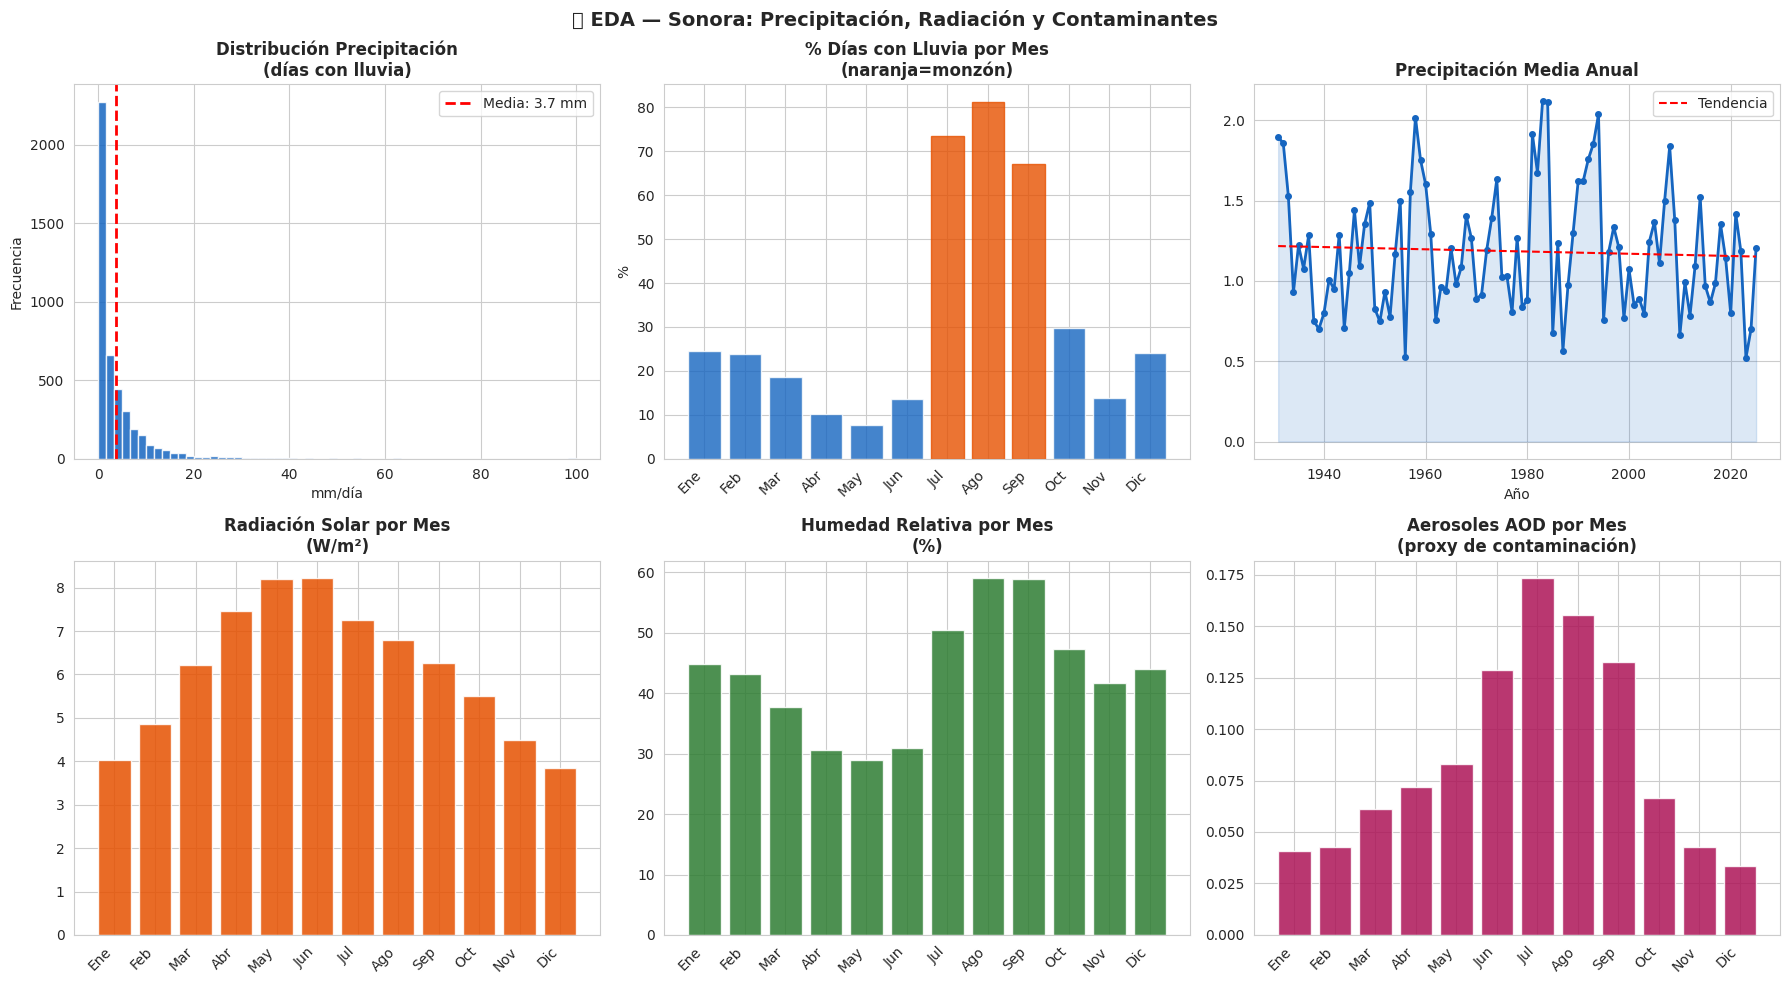

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10)) # Crea una cuadrícula de 2 filas y 3 columnas para las gráficas

fig.suptitle('EDA — Sonora: Precipitación, Radiación y Contaminantes', # Añade un título
             fontsize=14, fontweight='bold')

# Lista de etiquetas para los meses y extracción del número de mes de la columna FECHA
MESES = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
df['MES'] = df['FECHA'].dt.month

# Distribución de Histograma
ax = axes[0,0]
# Filtra solo los días donde sí llovió
p = df[df['PRECIP_mean']>0]['PRECIP_mean']
ax.hist(p, bins=60, color=PAL[0], edgecolor='white', alpha=0.85)
ax.axvline(p.mean(), color='red', lw=2, ls='--', label=f'Media: {p.mean():.1f} mm')
ax.set_title('Distribución Precipitación\n(días con lluvia)', fontweight='bold')
ax.set_xlabel('mm/día'); ax.set_ylabel('Frecuencia'); ax.legend()

#% de días con lluvia por mes
ax = axes[0,1]
# Agrupa por mes y calcula qué porcentaje de días tienen lluvia > 0
pct_mes = df.groupby('MES').apply(lambda x: (x['PRECIP_mean']>0).mean()*100)
bars = ax.bar(range(1,13), pct_mes, color=PAL[0], alpha=0.8, edgecolor='white')
for i in [7,8,9]: bars[i-1].set_color(PAL[2])
ax.set_xticks(range(1,13)); ax.set_xticklabels(MESES, rotation=45, ha='right')
ax.set_title('% Días con Lluvia por Mes\n(naranja=monzón)', fontweight='bold')
ax.set_ylabel('%')

# Precipitación
ax = axes[0,2]
# Calcula el promedio de lluvia por cada año
pa = df.groupby(df['FECHA'].dt.year)['PRECIP_mean'].mean()
ax.plot(pa.index, pa.values, color=PAL[0], lw=2, marker='o', ms=4)
ax.fill_between(pa.index, pa.values, alpha=0.15, color=PAL[0])
# Calcula y dibuja una línea de tendencia
z = np.polyfit(pa.index, pa.values, 1)
ax.plot(pa.index, np.poly1d(z)(pa.index), 'r--', lw=1.5, label='Tendencia')
ax.set_title('Precipitación Media Anual', fontweight='bold')
ax.set_xlabel('Año'); ax.legend()

# Radiación solar mensual
ax = axes[1,0]
ax.bar(range(1,13), df.groupby('MES')['ALLSKY_SFC_SW_DWN'].mean(),
       color=PAL[2], alpha=0.85, edgecolor='white')
ax.set_xticks(range(1,13)); ax.set_xticklabels(MESES, rotation=45, ha='right')
ax.set_title('Radiación Solar por Mes\n(W/m²)', fontweight='bold')

# Humedad mensual
ax = axes[1,1]
ax.bar(range(1,13), df.groupby('MES')['RH2M'].mean(),
       color=PAL[1], alpha=0.85, edgecolor='white')
ax.set_xticks(range(1,13)); ax.set_xticklabels(MESES, rotation=45, ha='right')
ax.set_title('Humedad Relativa por Mes\n(%)', fontweight='bold')

# Contaminación
ax = axes[1,2]
# AOD (Optical Depth) mide qué tan "sucia" está la atmósfera
ax.bar(range(1,13), df.groupby('MES')['AOD_55'].mean(),
       color=PAL[3], alpha=0.85, edgecolor='white')
ax.set_xticks(range(1,13)); ax.set_xticklabels(MESES, rotation=45, ha='right')
ax.set_title('Aerosoles AOD por Mes\n(proxy de contaminación)', fontweight='bold')

plt.tight_layout()
plt.savefig('eda.png', dpi=150, bbox_inches='tight')# Guarda la imagen
plt.show()# Muestra el resultado en pantalla

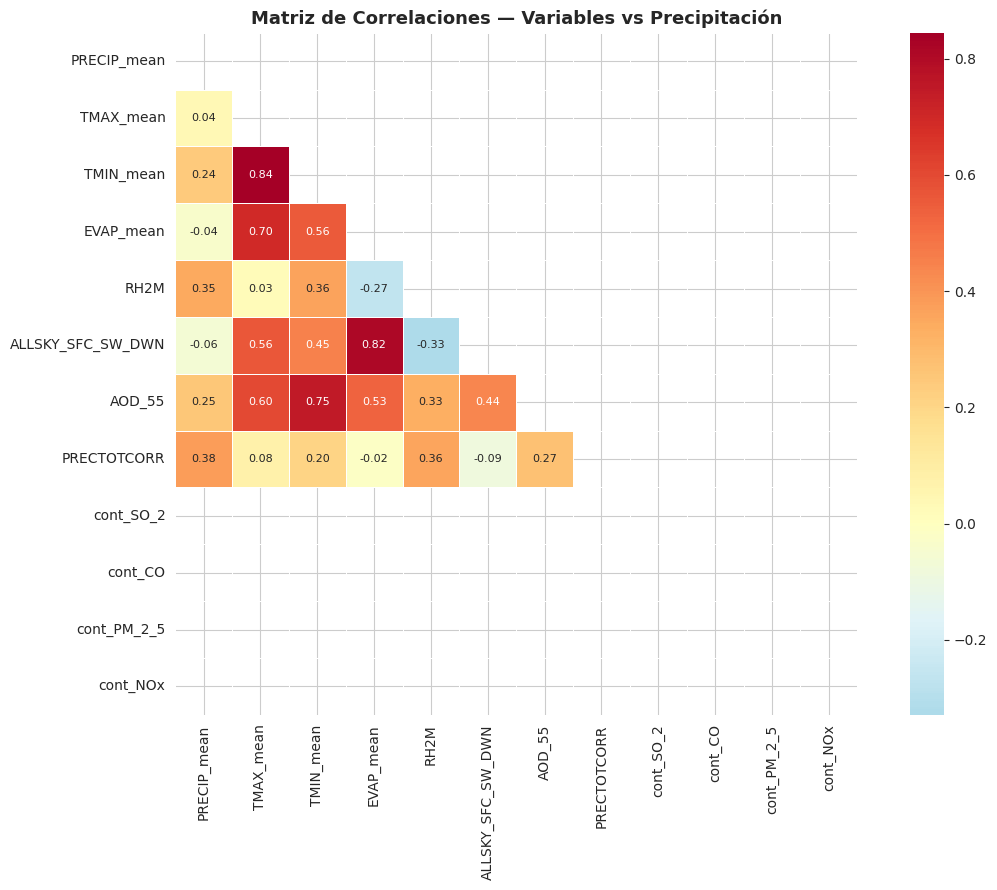

In [4]:
# Define la lista de columnas que se analizarán
cols_corr = ['PRECIP_mean','TMAX_mean','TMIN_mean','EVAP_mean',
             'RH2M','ALLSKY_SFC_SW_DWN','AOD_55','PRECTOTCORR',
             'cont_SO_2','cont_CO','cont_PM_2_5','cont_NOx']

corr = df[cols_corr].corr() # Calcula la matriz de correlación
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))

# Dibuja el mapa de calor usando Seaborn:
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=0.5, annot_kws={'size':8}, ax=ax)

# Añade el título principal a la gráfica
ax.set_title('Matriz de Correlaciones — Variables vs Precipitación',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('correlaciones.png', dpi=150, bbox_inches='tight') # Guarda el mapa de calor como una imagen

plt.show() # Muestra el gráfico

In [5]:
# Ordena los datos cronológicamente por fecha
df = df.sort_values('FECHA').reset_index(drop=True)

# Variable Objetivo
# Crea una columna binaria: 1 si llovió, 0 si no llovió
df['LLUVIA'] = (df['PRECIP_mean'] > 0).astype(int)

# Transformaciones Cíclicas
# Convertimos el mes y el día en coordenadas
df['mes_sin'] = np.sin(2*np.pi*df['MES']/12)
df['mes_cos'] = np.cos(2*np.pi*df['MES']/12)
df['dia_año'] = df['FECHA'].dt.dayofyear # Número de día del 1 al 365
df['dia_sin'] = np.sin(2*np.pi*df['dia_año']/365)
df['dia_cos'] = np.cos(2*np.pi*df['dia_año']/365)

# Lags
df['precip_lag1']    = df['PRECIP_mean'].shift(1) # Lluvia de ayer
df['precip_lag3']    = df['PRECIP_mean'].shift(3) # Lluvia de hace 3 días
df['rh_lag1']        = df['RH2M'].shift(1)        # Humedad de ayer
df['radiacion_lag1'] = df['ALLSKY_SFC_SW_DWN'].shift(1)

# Medias Móviles
# Calcula el promedio de la última semana
df['precip_roll7']    = df['PRECIP_mean'].rolling(7, min_periods=1).mean()
df['radiacion_roll7'] = df['ALLSKY_SFC_SW_DWN'].rolling(7, min_periods=1).mean()
df['rh_roll7']        = df['RH2M'].rolling(7, min_periods=1).mean()

# Otras Variables
# Calcula la diferencia entre temperatura máxima y mínima
df['amp_termica'] = df['TMAX_mean'] - df['TMIN_mean']
df['AÑO'] = df['FECHA'].dt.year
df = df.dropna(subset=['LLUVIA']).reset_index(drop=True)

# Definimos la lista final de columnas que se usarán para predecir
FEATURES = ['TMAX_mean','TMIN_mean','EVAP_mean','amp_termica',
            'RH2M','ALLSKY_SFC_SW_DWN','AOD_55','PRECTOTCORR',
            'precip_lag1','precip_lag3','rh_lag1','radiacion_lag1',
            'precip_roll7','radiacion_roll7','rh_roll7',
            'mes_sin','mes_cos','dia_sin','dia_cos',
            'cont_SO_2','cont_CO','cont_NOx','cont_COV','cont_PM_010','cont_PM_2_5']

# División de Datos
# Se usarán los datos hasta 2019 para entrenar y de 2020 en adelante para evaluar
X_tr = df.loc[df['AÑO']<=2019, FEATURES]
y_tr = df.loc[df['AÑO']<=2019, 'LLUVIA']
X_te = df.loc[df['AÑO']>=2020, FEATURES]
y_te = df.loc[df['AÑO']>=2020, 'LLUVIA']

# Limpieza y Normalización
imp = SimpleImputer(strategy='median')
X_tr_i = imp.fit_transform(X_tr); X_te_i = imp.transform(X_te)
sc  = StandardScaler()
X_tr_s = sc.fit_transform(X_tr_i); X_te_s = sc.transform(X_te_i)

# Imprime el resumen final
print(f"   TRAIN: {X_tr_s.shape[0]:,} | TEST: {X_te_s.shape[0]:,}")
print(f"   Features: {len(FEATURES)}")
print(f"   Lluvia TRAIN: {y_tr.mean()*100:.1f}% | TEST: {y_te.mean()*100:.1f}%")

✅ TRAIN: 12,805 | TEST: 840
   Features: 25
   Lluvia TRAIN: 31.8% | TEST: 40.8%


In [6]:
print("🔵 Entrenando Regresión Logística...")

# Configura el modelo de Regresión Logística
lr = LogisticRegression(max_iter=2000, C=0.5,
                        class_weight='balanced', random_state=42)

lr.fit(X_tr_s, y_tr) # Entrena el modelo usando los datos de entrenamiento
yp_lr  = lr.predict(X_te_s) # Realiza las predicciones
ypr_lr = lr.predict_proba(X_te_s)[:,1] # Calcula la probabilidad

# Cálculo de Métricas de Evaluación
acc_lr = accuracy_score(y_te, yp_lr) # Calcula la exactitud
f1_lr  = f1_score(y_te, yp_lr) # Calcula el F1-Score
auc_lr = roc_auc_score(y_te, ypr_lr) # Calcula el área bajo la curva ROC

# Imprime los resultados
print(f"    Accuracy={acc_lr:.4f} | F1={f1_lr:.4f} | AUC={auc_lr:.4f}")

🔵 Entrenando Regresión Logística...
   ✅ Accuracy=0.8310 | F1=0.7760 | AUC=0.8925


In [7]:
print("🟢 Entrenando Random Forest...")

# Configura el Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=15,
                             min_samples_leaf=4, class_weight='balanced',
                             random_state=42, n_jobs=-1)

rf.fit(X_tr_i, y_tr) # Entrena el modelo.
yp_rf  = rf.predict(X_te_i) # Realiza las predicciones de categoría
ypr_rf = rf.predict_proba(X_te_i)[:,1] # Calcula las probabilidades de lluvia

# Cálculo de Métricas
acc_rf = accuracy_score(y_te, yp_rf) # Porcentaje de aciertos totales
f1_rf  = f1_score(y_te, yp_rf) # Balance entre precisión y sensibilidad
auc_rf = roc_auc_score(y_te, ypr_rf)# Capacidad del modelo para separar las clases
print(f"    Accuracy={acc_rf:.4f} | F1={f1_rf:.4f} | AUC={auc_rf:.4f}")

🟢 Entrenando Random Forest...
   ✅ Accuracy=0.8655 | F1=0.8270 | AUC=0.9346


In [8]:
print("🟠 Entrenando XGBoost...")

spw = (y_tr==0).sum()/(y_tr==1).sum()

# Configura el modelo XGBoost:
xgb_m = xgb.XGBClassifier(n_estimators=500, max_depth=6,
                            learning_rate=0.03, subsample=0.8,
                            colsample_bytree=0.8, scale_pos_weight=spw,
                            eval_metric='auc', random_state=42,
                            verbosity=0, n_jobs=-1)

xgb_m.fit(X_tr_i, y_tr, eval_set=[(X_te_i,y_te)], verbose=False) # Entrena el modelo.
yp_xgb  = xgb_m.predict(X_te_i) # Realiza las predicciones finales
ypr_xgb = xgb_m.predict_proba(X_te_i)[:,1] # Calcula las probabilidades de lluvia

# Cálculo de Métricas
acc_xgb = accuracy_score(y_te, yp_xgb) # Exactitud total
f1_xgb  = f1_score(y_te, yp_xgb)       # Precisión y recuperación
auc_xgb = roc_auc_score(y_te, ypr_xgb) # Capacidad de distinguir clases
print(f"   ✅ Accuracy={acc_xgb:.4f} | F1={f1_xgb:.4f} | AUC={auc_xgb:.4f}")

🟠 Entrenando XGBoost...
   ✅ Accuracy=0.8595 | F1=0.8275 | AUC=0.9340


In [9]:
print("🔴 Preparando LSTM...")
# Definimos el tamaño de la ventana
WINDOW = 10

# Función para transformar los datos en secuencias
def make_seq(X, y, w):
    # Crea una lista de fragmentos de 'w' días y los convierte en arreglos de NumPy
    return (np.array([X[i-w:i] for i in range(w,len(X))]),
            np.array(y[w:]))

# Creamos las secuencias para entrenamiento y para prueba
Xts, yts = make_seq(X_tr_s, y_tr.values, WINDOW)
Xes, yes = make_seq(X_te_s, y_te.values, WINDOW)
print(f"   TRAIN: {Xts.shape} | TEST: {Xes.shape}")
tf.random.set_seed(42)

# Calculamos los pesos de las clases para manejar el desbalance
cw = {0:1.0, 1:(yts==0).sum()/(yts==1).sum()}

lstm_m = Sequential([
    # Capa de entrada
    Input(shape=(WINDOW, Xts.shape[2])),
    # Primera capa LSTM: extrae patrones temporales
    LSTM(64, return_sequences=True), Dropout(0.2),
    # Segunda capa LSTM: resume la información de la secuencia
    LSTM(32), Dropout(0.2),
    # Capa densa para procesar las características extraídas
    Dense(16, activation='relu'),
    # Capa de salida
    Dense(1, activation='sigmoid')
])

# Compilación del modelo
lstm_m.compile(optimizer='adam', loss='binary_crossentropy',
               metrics=['accuracy'])
cbs = [EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]

# Entrenamiento de la red
lstm_m.fit(Xts, yts, epochs=60, batch_size=64,
           validation_split=0.2, class_weight=cw, # Usa el 20% de los datos
           callbacks=cbs, verbose=1)

# Realizamos las predicciones con los datos de prueba
ypr_lstm = lstm_m.predict(Xes, verbose=0).flatten()
# Convertimos la probabilidad
yp_lstm  = (ypr_lstm>=0.5).astype(int)

# Cálculo de Métricas
acc_lstm = accuracy_score(yes, yp_lstm)
f1_lstm  = f1_score(yes, yp_lstm)
auc_lstm = roc_auc_score(yes, ypr_lstm)

print(f"\n    Accuracy={acc_lstm:.4f} | F1={f1_lstm:.4f} | AUC={auc_lstm:.4f}")

🔴 Preparando LSTM...
   TRAIN: (12795, 10, 25) | TEST: (830, 10, 25)
Epoch 1/60
160/160 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.7271 - loss: 0.7711 - val_accuracy: 0.7773 - val_loss: 0.5015
Epoch 2/60
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7954 - loss: 0.6785 - val_accuracy: 0.7749 - val_loss: 0.5026
Epoch 3/60
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8001 - loss: 0.6596 - val_accuracy: 0.7776 - val_loss: 0.5022
Epoch 4/60
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8042 - loss: 0.6433 - val_accuracy: 0.7808 - val_loss: 0.4935
Epoch 5/60
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8031 - loss: 0.6324 - val_accuracy: 0.7902 - val_loss: 0.4858
Epoch 6/60
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8123 - loss: 0.6182 - val_accuracy: 0.8015 - val_loss: 0.4853
Epoch 7/60
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.8186 - loss: 0.6018 - val_accuracy: 0.8034 - val_loss: 0.4739
Epoch 8/60
160/160 ━━━━━━━━

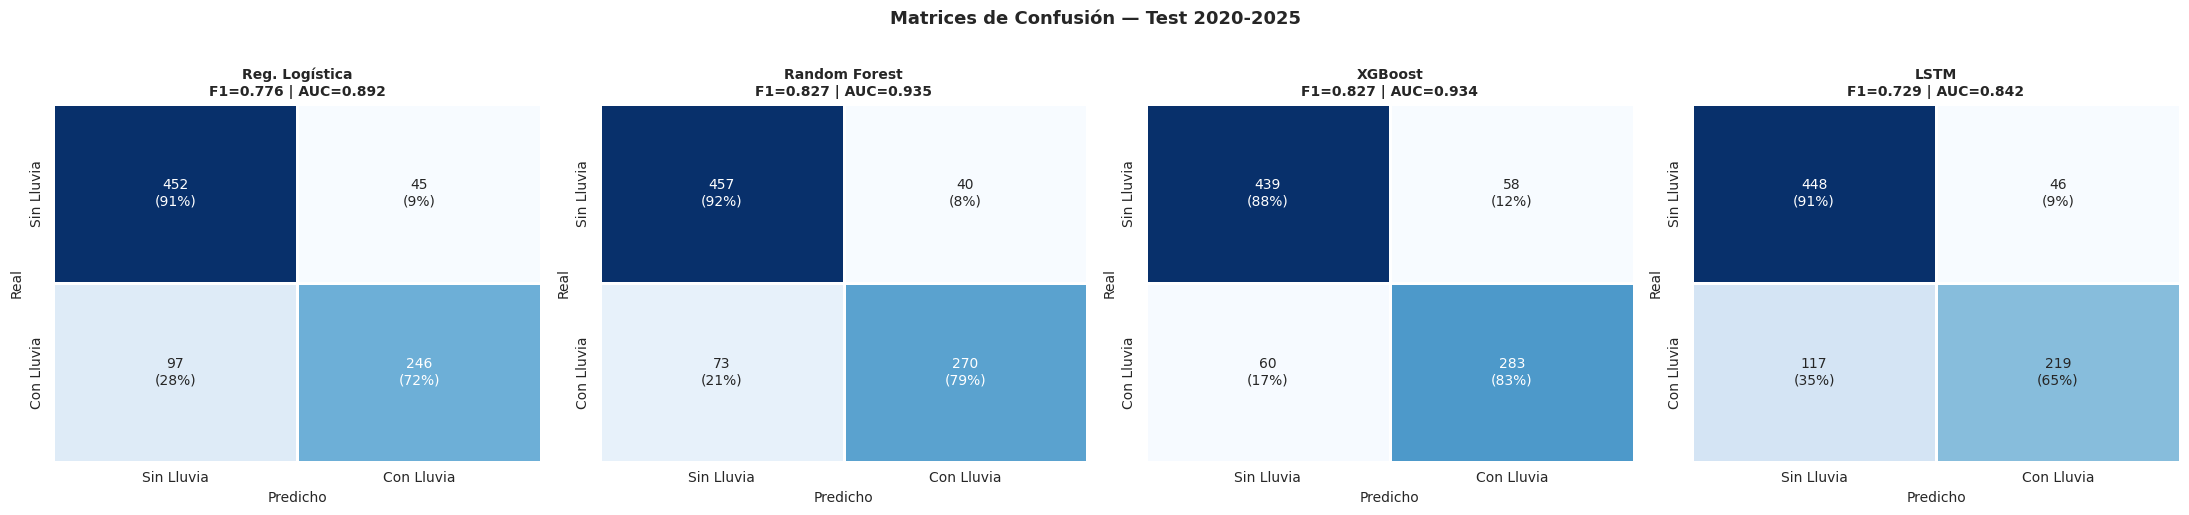

In [10]:
# Creamos una lista con los resultados de todos los modelos
MODELOS = [
    ('Reg. Logística', yp_lr,   y_te,  ypr_lr,  PAL[0]),
    ('Random Forest',  yp_rf,   y_te,  ypr_rf,  PAL[1]),
    ('XGBoost',        yp_xgb,  y_te,  ypr_xgb, PAL[2]),
    ('LSTM',           yp_lstm, yes,   ypr_lstm, PAL[3]),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Matrices de Confusión — Test 2020-2025',
             fontsize=13, fontweight='bold', y=1.02)

for ax, (nom, yp, yt, _, col) in zip(axes, MODELOS):

    cm = confusion_matrix(yt, yp)# Calcula la matriz de confusión
    cm_pct = cm/cm.sum(axis=1, keepdims=True)*100 # Convierte los valores a porcentajes
    annot = np.array([[f"{v}\n({p:.0f}%)" for v,p in zip(rv,rp)] # Crea las etiquetas de texto
                      for rv,rp in zip(cm, cm_pct)])

    # Dibuja el mapa Heatmap)
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=ax,
                linewidths=2, cbar=False,
                xticklabels=['Sin Lluvia','Con Lluvia'],
                yticklabels=['Sin Lluvia','Con Lluvia'])

    # Calcula las métricas rápidas
    f1  = f1_score(yt, yp)
    acc = accuracy_score(yt, yp)
    auc = roc_auc_score(yt, _)

    # Configura el título y etiquetas de cada sub-gráfica
    ax.set_title(f'{nom}\nF1={f1:.3f} | AUC={auc:.3f}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
plt.tight_layout()

# Guarda la comparación
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
# Muestra el resultado
plt.show()

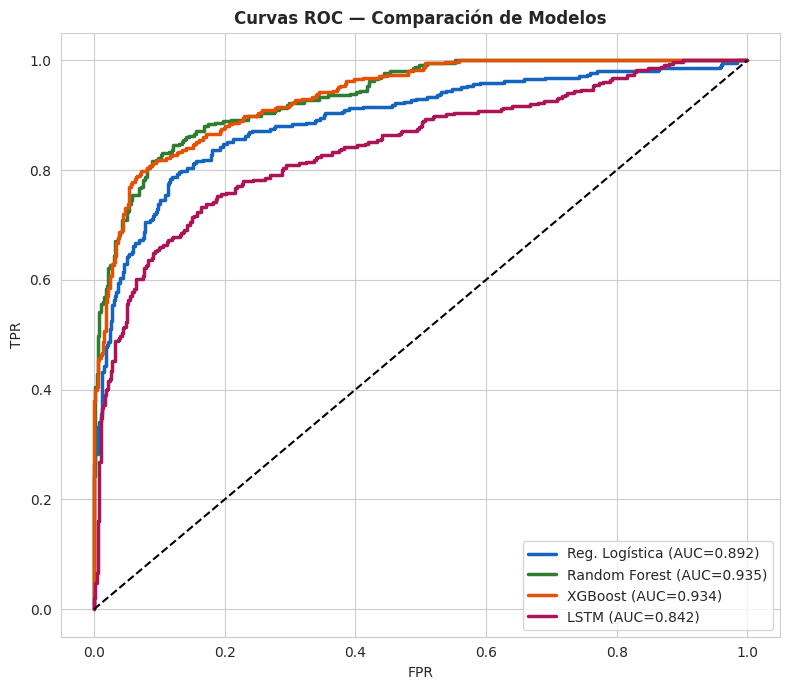


  TABLA COMPARATIVA DE MODELOS
  XGBoost              F1=0.8275  AUC=0.9340
  Random Forest        F1=0.8270  AUC=0.9346
  Reg. Logística       F1=0.7760  AUC=0.8925
  LSTM                 F1=0.7288  AUC=0.8416

  🏆 Mejor: XGBoost


In [11]:
# Gráfico de Curvas ROC
fig, ax = plt.subplots(figsize=(8, 7))

for nom, yp, yt, ypr, col in MODELOS:
    # Calcula la Tasa de Falsos Positivos y la Tasa de Verdaderos Positivos
    fpr, tpr, _ = roc_curve(yt, ypr)
    ax.plot(fpr, tpr, lw=2.5, color=col,
            label=f"{nom} (AUC={roc_auc_score(yt,ypr):.3f})")

ax.plot([0,1],[0,1],'k--', lw=1.5)

# Etiquetas de los ejes
ax.set_xlabel('FPR (Falsos Positivos)'); ax.set_ylabel('TPR (Verdaderos Positivos)')
ax.set_title('Curvas ROC — Comparación de Modelos', fontweight='bold')
ax.legend(loc='lower right') # Coloca la leyenda en la esquina inferior derecha

plt.tight_layout()
plt.savefig('curvas_roc.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla de Métricas
# Crea un DataFrame para organizar los resultados
res = pd.DataFrame({
    'Modelo':   ['Reg. Logística','Random Forest','XGBoost','LSTM'],
    'Accuracy': [acc_lr, acc_rf, acc_xgb, acc_lstm],
    'F1-Score': [f1_lr,  f1_rf,  f1_xgb,  f1_lstm],
    'AUC-ROC':  [auc_lr, auc_rf, auc_xgb, auc_lstm]
}).sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("\n" + "="*55)
print("  TABLA COMPARATIVA DE MODELOS")
print("="*55)
for _, r in res.iterrows():
    print(f"  {r['Modelo']:<20} F1={r['F1-Score']:.4f}  AUC={r['AUC-ROC']:.4f}")

print(f"\n   Mejor: {res.iloc[0]['Modelo']}")

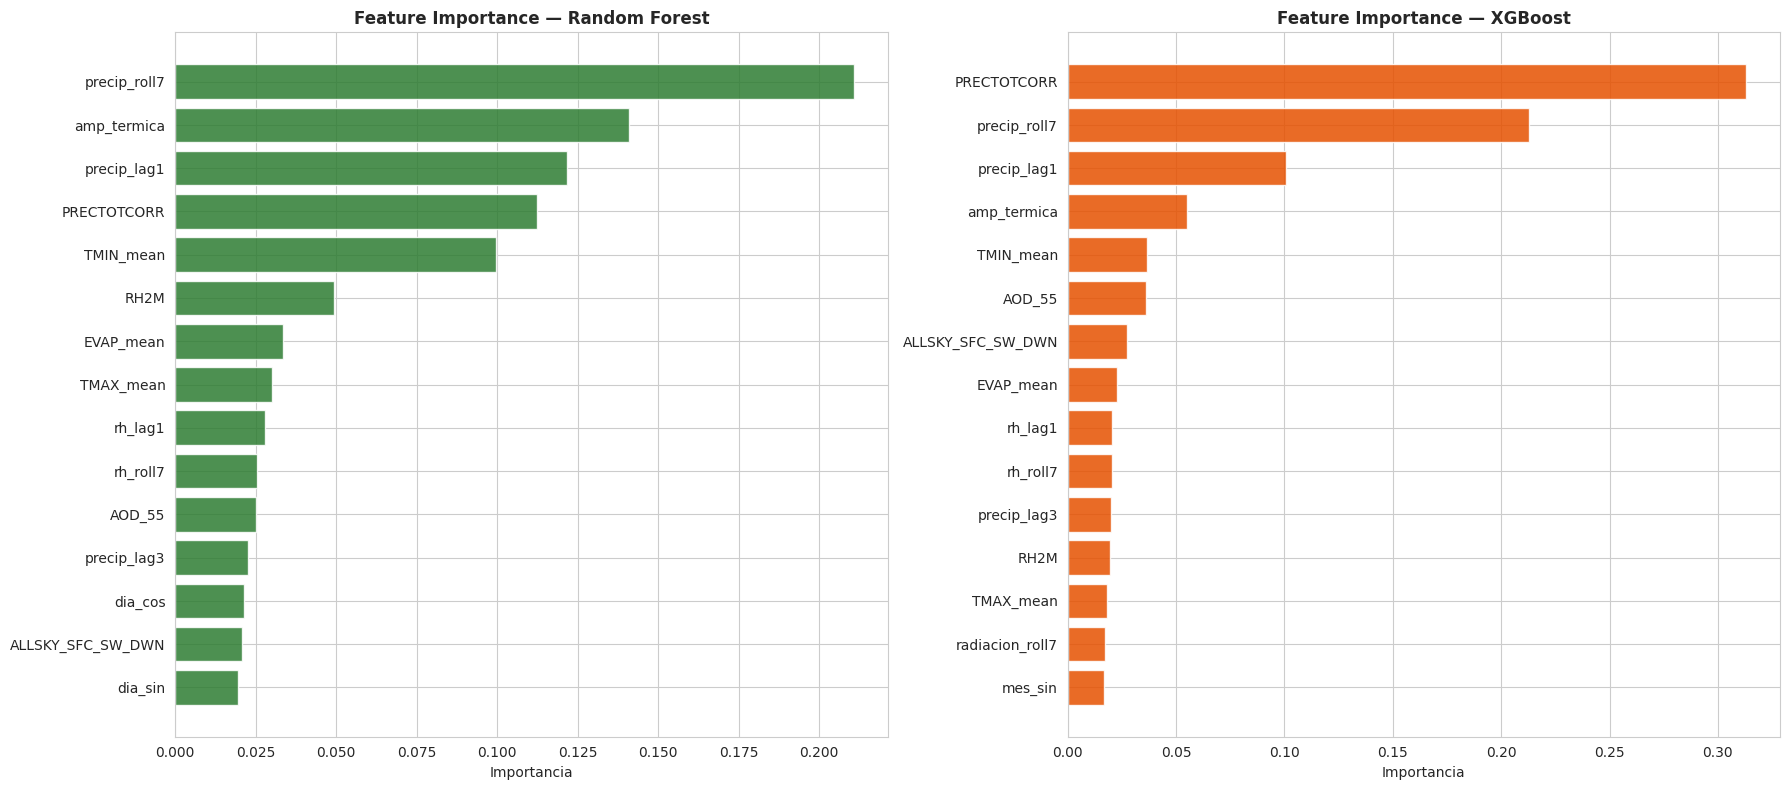

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Todo descargado


In [12]:
# Análisis de Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, (modelo, nombre, col) in zip(axes, [
    (rf,    'Random Forest', PAL[1]),
    (xgb_m, 'XGBoost',       PAL[2])
]):
    # Extrae la importancia de cada variable y seleccionamos las 15 más relevantes
    top = pd.Series(modelo.feature_importances_,
                    index=FEATURES).sort_values().tail(15)
    ax.barh(top.index, top.values, color=col, edgecolor='white', alpha=0.85)
    ax.set_title(f'Feature Importance — {nombre}', fontweight='bold')
    ax.set_xlabel('Importancia (Peso en la decisión)')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Exportación de Resultados
# Guarda la tabla comparativa de los modelos
res.to_csv('metricas_finales.csv', index=False)

# Descarga Automática
from google.colab import files
archivos = ['metricas_finales.csv', 'confusion_matrices.png',
            'curvas_roc.png', 'feature_importance.png',
            'eda.png', 'correlaciones.png']
for f in archivos:
    try:
        files.download(f)
    except:
        pass

print(" Todo descargado")